In [227]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cvxopt as opt

import importlib

import markowitz_optimization
importlib.reload(markowitz_optimization)

<module 'markowitz_optimization' from 'c:\\Users\\User\\Desktop\\Github-local\\GFWM\\gfwm-app\\data_science\\quant\\markowitz_optimization.py'>

In [228]:
all_price_data = pd.read_csv("sp500_daily_data.csv")[["ticker", "log_return", "volatility"]]

entire_cov_matrix = pd.read_csv("sp500_covariance_matrix.csv")
entire_cov_matrix = entire_cov_matrix.set_index('ticker')

unique_tickers = pd.Series(all_price_data['ticker'].unique())

n=200
tickers = unique_tickers.sample(frac=(n+1)/500, random_state=1).reset_index(drop=True)

# keep selected tickers
price_data = all_price_data[all_price_data['ticker'].isin(tickers)]

# keep entries where both tickers are present
cov_matrix = entire_cov_matrix.loc[tickers, tickers].to_numpy()

mean_log_returns = price_data.groupby(by="ticker").log_return.agg("mean")
mu_bar = np.mean(mean_log_returns)
mu_sd = np.std(mean_log_returns)

# Convert to cvxopt matrices
cov = opt.matrix(cov_matrix)
mean_returns = opt.matrix(mean_log_returns)

# annual risk free rate
risk_free_rate = 0.03

# daily target returns. scale to annual for graphing
target_returns = np.linspace(start=mu_bar - 0.25*mu_sd, stop=mu_bar + 0.7*mu_sd, num=60)

#print(target_returns * 252 * 100)

In [233]:
# generate portfolios
montecarlo_portfolios = markowitz_optimization.montecarlo_random_portfolios(mean_returns, cov, [0.0, 4.0/n])

optimal_portfolios, best_fit = markowitz_optimization.calculate_optimal_portfolios(mean_returns, cov, target_returns, 
                                                                                   annual_risk_free_rate= risk_free_rate, 
                                                                                   bounds = [0.5/n, 4.0/n])

     pcost       dcost       gap    pres   dres
 0: -2.4920e-04 -3.4757e+00  4e+02  2e+01  1e+01
 1: -2.6412e-04 -3.4003e+00  1e+01  4e-01  3e-01
 2: -2.5284e-04 -1.7870e+00  2e+00  5e-02  4e-02
 3: -2.4934e-04 -2.3984e-01  2e-01  3e-16  3e-15
 4: -2.4935e-04 -2.7777e-03  3e-03  1e-16  2e-15
 5: -2.5041e-04 -4.0412e-04  2e-04  3e-16  1e-16
 6: -2.6318e-04 -3.7201e-04  1e-04  4e-17  5e-17
 7: -2.7123e-04 -3.2339e-04  5e-05  6e-17  2e-17
 8: -2.7566e-04 -3.0569e-04  3e-05  1e-16  1e-17
 9: -2.7856e-04 -2.9741e-04  2e-05  9e-17  6e-18
10: -2.8055e-04 -2.9146e-04  1e-05  1e-16  4e-18
11: -2.8197e-04 -2.8847e-04  7e-06  3e-16  3e-18
12: -2.8285e-04 -2.8616e-04  3e-06  7e-17  2e-18
13: -2.8345e-04 -2.8480e-04  1e-06  4e-16  3e-18
14: -2.8391e-04 -2.8406e-04  2e-07  3e-16  3e-18
15: -2.8397e-04 -2.8398e-04  3e-09  4e-16  3e-18
Optimal solution found.
     pcost       dcost       gap    pres   dres
 0: -2.5513e-04 -3.4748e+00  4e+02  2e+01  1e+01
 1: -2.7015e-04 -3.3997e+00  1e+01  4e-01  3e-0

target_excess_return                                             0.000514
annual_return                                                    0.150031
annual_volatility                                                   0.177
weights                 [0.0025009429041034665, 0.0025004559741931354,...
diversification                                                   0.92761
Name: 43, dtype: object
99.99983489178301


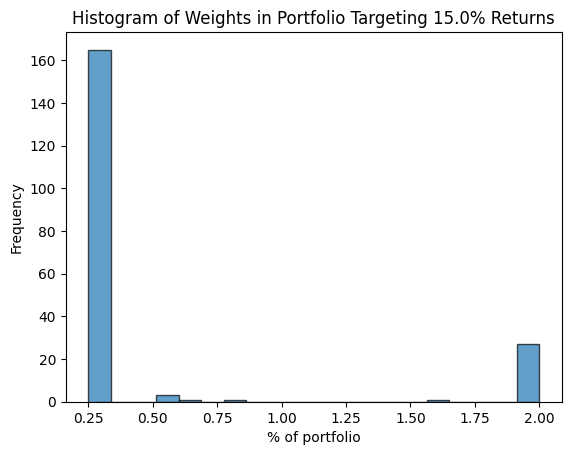

In [234]:
#find the portfolio nearest to 15% return

optimal_portfolios.sort_values(by='annual_return', ascending= True)
target_return = 0.15
closest_portfolio = optimal_portfolios.loc[(optimal_portfolios['annual_return'] - target_return).abs().idxmin()]
closest_portfolio_weights = closest_portfolio['weights'] * 100

print(closest_portfolio)

print(sum(closest_portfolio_weights))

plt.hist(closest_portfolio_weights, bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('% of portfolio')
plt.ylabel('Frequency')
plt.title(f'Histogram of Weights in Portfolio Targeting {target_return * 100}% Returns')
plt.show()

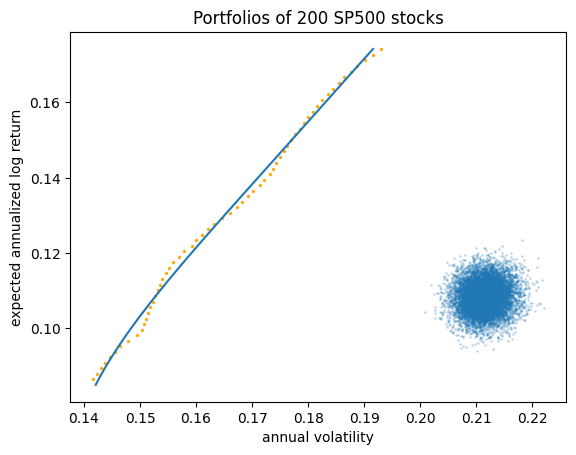

In [235]:
fig = plt.figure()

plt.scatter(montecarlo_portfolios['annual_volatility'],
            montecarlo_portfolios['annual_return'], s=1, alpha=0.2)

plt.scatter(optimal_portfolios['annual_volatility'],
            optimal_portfolios['annual_return'], s=2, c='orange', alpha=0.9)

plt.ylabel('expected annualized log return')
plt.xlabel('annual volatility')

plt.plot([best_fit(tgt*252.0) for tgt in target_returns], [tgt*252.0 for tgt in target_returns])

plt.title(f"Portfolios of {n} SP500 stocks")
plt.show()

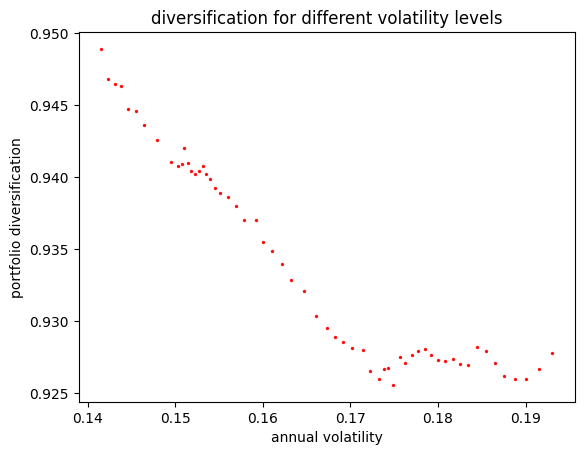

In [236]:
plt.scatter(optimal_portfolios['annual_volatility'],
            optimal_portfolios['diversification'], s=2, c='red', alpha=0.9)
plt.xlabel('annual volatility')
plt.ylabel('portfolio diversification')
plt.title('diversification for different volatility levels')
plt.show()